All raw data used for the project are available for viewing at https://github.com/vk4444/DATA301_Project/tree/main

LLMs were used rarely throughout this project and never to generate blocks of text or code. All searches and prompts can be found in the Searches Documentation document which was attached to the assignment submission.

In [1]:
# @title Installations

!pip install -U pypdfium2
!pip install "dask[distributed]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 867.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.5 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/vk4444/DATA301_Project.git

Cloning into 'DATA301_Project'...
remote: Enumerating objects: 1614, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 1614 (delta 38), reused 11 (delta 2), pack-reused 1500 (from 2)
Receiving objects: 100% (1614/1614), 712.94 MiB | 29.58 MiB/s, done.
Resolving deltas: 100% (58/58), done.
Updating files: 100% (1409/1409), done.


In [3]:
# @title Imports

import dask.bag as db
import dask.dataframe as ddf
import dask.array as da
import pandas as pd
import numpy as np
import pypdfium2 as pdfium
import re
import time
import random
from dask.diagnostics import ProgressBar
from google.colab import output

In [36]:
# ensures reproducibility of results
random.seed(42)

In [4]:
# # Dast distributed
# from dask.distributed import LocalCluster
# cluster = LocalCluster()          # Fully-featured local Dask cluster
# client = cluster.get_client()

# Load datasets into the notebook

In [37]:
# @title Book File Names
book_file_names = ['babicka_bozena_nemcova',
'windows8_redakce_businessIT_a_partneri',
'cesky_rozhlas-historie_eva_jesutova_a_kolektiv',
'flvek_05_alois_jirasek',
'flvek_4_alois_jirasek',
'flvek_03_alois_jirasek',
'flvek_02_alois_jirasek',
'flvek_01_alois_jirasek',
'jihoslovanske_jazyky_pavel_krejci',
'nase_nynejsi_krise_tomas_garrigue_masaryk',
'lucerna_alois_jirasek',
'matka_karel_capek',
'basne_josef_vaclav_sladek',
'dalimilova_kronika_dalimil',
'obycejny_zivot_karel_capek',
'povetron_karel_capek',
'hordubal_karel_capek',
'noc_na_karlstejne_jaroslav_vrchlicky',
'pisne_kosmicke_jan_neruda',
'domaci_kucharka_magdalena_dobromila_rettigova',
'hovory_s_tg_masarykem_karel_capek',
'dramaticke_zlomky_karel_hynek_macha',
'povidani_o_pejskovi_a_kocicce_josef_capek',
'obrazy_z_dejin_naroda_ceskeho_iii_vladislav_vancura',
'obrazy_z_dejin_naroda_ceskeho_ii_vladislav_vancura',
'obrazy_z_dejin_naroda_ceskeho_i_vladislav_vancura',
'rur_karel_capek',
'bylo_nas_pet_karel_polacek',
'mistr_kampanus_zikmund_winter',
'konec_starych_casu_vladislav_vancura',
'ballady_a_romance_jan_neruda',
'vec_makropulos_karel_capek',
'krakatit_karel_capek',
'filosofska_historie_alois_jirasek',
'stare_povesti_ceske_alois_jirasek',
'devatero_pohadek_karel_capek',
'kosmuw_letopis_cesky_kosmas',
'tezka_hodina_jiri_wolker',
'host_do_domu_jiri_wolker',
'nova_evropa_tomas_garrigue_masaryk',
'sedm_let_v_jizni_africe_iv_emil_holub',
'sedm_let_v_jizni_africe_iii_emil_holub',
'sedm_let_v_jizni_africe_druha_cesta_emil_holub',
'sedm_let_v_jizni_africe_prvni_cesta_emil_holub',
'bila_nemoc_karel_capek',
'rozmarne_leto_vladislav_vancura',
'maj_karel_hynek_macha',
'kytice_karel_jaromir_erben',
'osudy_dobreho_vojaka_svejka_jaroslav_hasek_volumes3and4',
'osudy_dobreho_vojaka_svejka_jaroslav_hasek_volumes1and2',
'broucci_jan_karafiat',
]

This is the dictionnary of abbreviations that will be expanded. This is done so that the text corresponds to how it would be pronounced and to correctly separate the sentences later. The dictionnary was adapted from https://cja.ujc.cas.cz/e-cja/zkratky which lists some of the most common abbreviations in the Czech Language. The dictionnary is not exhaustive and some of the abbreviations might have different interpretations in certain contexts.

In [38]:
# @title Utility Functions

# loads books and converts from pdf to txt
def book_loader(filename: str) -> tuple[str, str]:
  document = pdfium.PdfDocument('DATA301_Project/books/' + filename + '.pdf')

  version_marker_found = 0
  book_started = 0
  text = ''
  for page in document:
    # extract text from the page
    textpage = page.get_textpage()
    extractedtext = textpage.get_text_bounded()

    # the following two conditions ensure that the material attached to the book that is not a part of the original text is skipped (for example the cover page, info about publication etc.)
    if version_marker_found == 0 and 'verze' in extractedtext.lower():
      version_marker_found = 1
      print('version marker found')

    # after the version marker is found (indicating the last page of added material), the next page is checked for containing the contents (obsah) of the book which can also be skipped.
    elif version_marker_found and book_started == 0:
      if 'obsah' not in extractedtext.lower():
        book_started = 1

    if book_started:
      text += extractedtext

  return filename, text

# generates urls for all the wiki files
def generate_wiki_urls(last_chr: str = 'N', last_number: int = 55, sample_size: int = 0) -> list[str]:
  urls = []
  current_chr = 'A'
  current_num_str = '00'

  # generates urls for all the files
  while ord(current_chr) <= ord(last_chr):
    n_of_files = 100

    if ord(current_chr) == ord(last_chr):
      n_of_files = last_number + 1

    for i in range(n_of_files):
      if i < 10:
        current_num_str = '0' + str(i)
      else:
        current_num_str = str(i)

      urls.append('DATA301_Project/wiki/A' + current_chr + '/' + 'wiki_' + current_num_str)

    current_chr = chr(ord(current_chr) + 1)

  if sample_size:
    urls = random.sample(urls, k=sample_size)

  return urls

In [39]:
# wiki loader samples correctly
assert len(generate_wiki_urls(sample_size=100)) == 100

In [40]:
# @title Loading the Data
# load the books
books = db.from_sequence(book_file_names).map(book_loader)

# load the Czech Wikipedia
# number of 1MB files loaded
sample_size = 20
wiki = (
    db.read_text(generate_wiki_urls(sample_size=sample_size))
    .filter(lambda x: x[:4] != '<doc' and '__NOEDITSECTION__' not in x and '</doc>' not in x)
    .map(lambda x: ('wiki', x))
)

books = books.repartition(npartitions=1)
wiki = wiki.repartition(npartitions=int(sample_size/100) + 1)

survey_anonymized = ddf.read_csv('DATA301_Project/survey/anonymized_data.csv', na_values=['<NA>'])

all_text = db.concat([wiki, books])

In [9]:
with ProgressBar():
  result = wiki.compute()

[########################################] | 100% Completed | 2.03 s


In [10]:
# verify all files have loaded correctly
# assert books.npartitions == 2
# assert wiki.npartitions == 2

In [51]:
# look at the first few items of text
print(books.take(15))

(('babicka_bozena_nemcova', '5\r\nÚvod\r\nDávno, dávno již tomu, co jsem posledně se dívala do té milé \r\nmírné tváře, co jsem zulíbala to bledé líce, plné vrásků, nahlížela do \r\nmodrého oka, v němž se jevilo tolik dobroty a lásky, dávno tomu, co \r\nmne posledně žehnaly staré její ruce! - Není více dobré stařenky! \r\nDávno již odpočívá v chladné zemi!\r\nMně ale neumřela! - Obraz její odtisknut v duši mé s veškerou \r\nsvojí barvitostí, a dokud zdráva zůstane, dotud bude žít v ní! -\r\nKdybych štětcem mistrně vládnout znala, oslavila bych tě, milá \r\nbabičko, jinak; ale nástin tento, perem kreslený - nevím, nevím, jak \r\nse komu zalíbí!\r\nTy jsi ale vždy říkala: „Není na světě člověk ten, aby se zachoval \r\nlidem všem.“ Dost na tom, když se najde jen několik čtenářů, kteří o \r\ntobě s takovou oblibou čísti budou, s jakou já o tobě píšu. 6\r\nI.\r\nBabička měla syna a dvě dcery. Nejstarší žila mnoho let ve Vídni \r\nu přátel, od nichž se vdala. Druhá dcera šla pak na její míst

In [12]:
# look at the first few rows of the survey
survey_anonymized.head()

,Unnamed: 0,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,...,A19_1,A20_1,A21_1,A22_1,A23_1,A24_1,A25_1,A26_1,A27_1,A28_1
0,0,Start Date,End Date,Response Type,anonymized,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...
1,1,"{""ImportId"":""startDate"",""timeZone"":""America/De...","{""ImportId"":""endDate"",""timeZone"":""America/Denv...","{""ImportId"":""status""}",anonymized,"{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""America...","{""ImportId"":""_recordId""}",...,"{""ImportId"":""QID23_1""}","{""ImportId"":""QID24_1""}","{""ImportId"":""QID25_1""}","{""ImportId"":""QID26_1""}","{""ImportId"":""QID27_1""}","{""ImportId"":""QID28_1""}","{""ImportId"":""QID29_1""}","{""ImportId"":""QID30_1""}","{""ImportId"":""QID31_1""}","{""ImportId"":""QID32_1""}"
2,2,2026-05-10 17:11:47,2026-05-10 17:13:19,Survey Preview,anonymized,100,91,True,2026-05-10 17:13:19,R_4JE55jXT7iFK35L,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,3,2026-05-10 18:20:56,2026-05-10 18:26:17,IP Address,anonymized,100,320,True,2026-05-10 18:26:18,R_9ZV8QTRGmaUyEur,...,87,87,80,75,68,77,<NA>,19,61,77
4,4,2026-05-10 18:37:15,2026-05-10 18:43:13,IP Address,anonymized,100,358,True,2026-05-10 18:43:14,R_9M4FuHomfPqmXye,...,61,63,22,38,71,70,65,86,95,95


# Data Pre-processing

In [13]:
# @title Dictionnary of Abbreviations

#adapted from https://cja.ujc.cas.cz/e-cja/zkratky
abbr_dict = {
    "adj.": "adjektivum",
    "adv.": "adverbium",
    "aj.": "a jiné",
    "akuz.": "akuzativ",
    "apod.": "a podobně",
    "atd.": "a tak dále",
    "býv.": "bývalý",
    "č.": "č",
    "čes.": "český",
    "dat.": "dativ",
    "dolož.": "doloženo",
    "doudl.": "doudlebský",
    "dř.": "dříve",
    "f.": "femininum",
    "gen.": "genitiv",
    "imp.": "imperativ",
    "ind.": "indikativ",
    "inf.": "infinitiv",
    "inform.": "informátor",
    "instr.": "instrumentál",
    "jč.": "jihočeský",
    "již.": "jižní",
    "jjv.": "jihojihovýchodní",
    "jjz.": "jihojihozápadní",
    "jv.": "jihovýchod",
    "jz.": "jihozápad",
    "jzč.": "jihozápadočeský",
    "km": "kilometr",
    "kol.": "kolektiv",
    "kond.": "kondicionál",
    "lid.": "lidový",
    "lok.": "lokál",
    "m.": "maskulinum",
    "m n. m.": "metry nad mořem",
    "min.": "minulý",
    "n. l.": "našeho letopočtu",
    "např.": "například",
    "nar.": "narozen",
    "nář.": "nářečí",
    "nepřízv.": "nepřízvučný",
    "neživ.": "neživotný",
    "nom.": "ominativ",
    "obl.": "oblast",
    "obyv.": "obyvatel",
    "okr.": "okres",
    "os.": "osoba",
    "pl.": "plurál",
    "plt.": "plurale tantum",
    "poč.": "počátek",
    "popř.": "popřípadě",
    "préz.": "prézens",
    "protet.": "protetický",
    "předp.": "předpona",
    "přech.": "přechodník",
    "příč.": "příčestí",
    "příp.": "přípona",
    "přísl.": "příslovce",
    "přít.": "přítomný",
    "přivl.": "přivlastňovací",
    "př. n. l.": "před naším letopočtem",
    "pův.": "původní",
    "r.": "rok",
    "s.": "strana",
    "samohl.": "samohláska",
    "sev.": "severní",
    "sg.": "singulár",
    "slez.": "slezský",
    "souhl.": "souhláska",
    "ssv.": "severoseverovýchodní",
    "ssz.": "severoseverozápadní",
    "stol.": "století",
    "střč.": "středočeský",
    "střm.": "středomoravský",
    "subst.": "substantivum",
    "sv.": "svatý",
    "svč.": "severovýchodočeský",
    "sz.": "severozápad",
    "tj.": "to je",
    "trp.": "trpný",
    "tř.": "třída",
    "tzn.": "to znamená",
    "tzv.": "takzvaný",
    "ukaz.": "ukazovací",
    "vjv.": "východojihovýchodní",
    "vm.": "východomoravský",
    "vok.": "vokativ",
    "vsv.": "východoseverovýchodní",
    "vých.": "východní",
    "zájm.": "zájmeno",
    "záp.": "západní",
    "zč.": "západočeský",
    "zjz.": "západojihozápadní",
    "zsz.": "západoseverozápadní",
    "zvl.": "zvláště",
    "zvrat.": "zvratný",
    "živ.": "životný"
}


In [90]:
# @title Utility Functions

# a function that removes every expression in a list from the given string
def clean_text(text: str, expr: list[str]) -> str:
  for e in expr:
    text = text.replace(e, '')
    print(e)

  return text

# splits a body of text into sentences
def to_sentences(item: tuple) -> list[tuple[str, str]]:
  name = item[0]
  text = item[1]
  sentences = []

  for sentence in re.split('\\.|\\!|\\?|\\:', text):
    sentences.append((name, sentence))

  return sentences

# converts dictionnary keys to regular expressions that look for the expression followed by non upper case letter character
def abbr_to_regex(expr: str) -> str:
  return '[\\s]' + expr.replace('.', '\\.') + '(?=\\s*[^\sA-Z])'

# expands abbreviations to their full form
def expand_abbr(text: str) -> str:
  for abbr in sorted(abbr_dict, key=len, reverse=True):
    regex = abbr_to_regex(abbr)
    text = re.sub(regex, abbr_dict[abbr], text)

  return text

# removes stopping signs that are used outside of the context of the end of sentence as determined by the following non-space character.
def remove_non_ending_stops(text) -> str:
    regex = '(\\.|\\!|\\:|\\;|\\?)(?=\\s*[^\sA-Z])'
    text = re.sub(regex, '', text)

    return text

def keep_printable(text: str) -> str:
  result = []
  for ch in text:
    if ch.isprintable():
      result.append(ch)

  return ''.join(result)

# converts "no"/"yes" string values to boolean
def yes_no_to_binary(text: str) -> int:
  if text == 'Yes':
    return 1
  else:
    return 0

def df_to_num(df):
  for col in df:
    df[col] = pd.to_numeric(df[col], errors='coerce')

  return df


<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_59702/2957463132.py:24: SyntaxWarning: invalid escape sequence '\s'
  return '[\\s]' + expr.replace('.', '\\.') + '(?=\\s*[^\sA-Z])'
/tmp/ipykernel_59702/2957463132.py:36: SyntaxWarning: invalid escape sequence '\s'
  regex = '(\\.|\\!|\\:|\\;|\\?)(?=\\s*[^\sA-Z])'


In [45]:
string = 'Vlajka Marshallových ostrovů je tvořena tmavě modrým listem o poměru stran 1:2 (původně 10:19, podle vlajky USA) se dvěma kosými, vějířovitě se rozšiřujícími pruhy, směřujícími z dolního rohu do horního cípu (viz vexilologické názvosloví). Horní trojúhelník je oranžový, dolní je bílý. V žerďovém poli je bílá hvězda se čtyřiadvaceti cípy. Čtyři z cípů jsou delší a směřují k okrajům listu.\n'

In [47]:
re.split('\\.|\\!|\\?|\\:', string)

['Vlajka Marshallových ostrovů je tvořena tmavě modrým listem o poměru stran 1',
 '2 (původně 10',
 '19, podle vlajky USA) se dvěma kosými, vějířovitě se rozšiřujícími pruhy, směřujícími z dolního rohu do horního cípu (viz vexilologické názvosloví)',
 ' Horní trojúhelník je oranžový, dolní je bílý',
 ' V žerďovém poli je bílá hvězda se čtyřiadvaceti cípy',
 ' Čtyři z cípů jsou delší a směřují k okrajům listu',
 '\n']

In [50]:
to_sentences(('wiki', string))

[('wiki',
  'Vlajka Marshallových ostrovů je tvořena tmavě modrým listem o poměru stran 1'),
 ('wiki', '2 (původně 10'),
 ('wiki',
  '19, podle vlajky USA) se dvěma kosými, vějířovitě se rozšiřujícími pruhy, směřujícími z dolního rohu do horního cípu (viz vexilologické názvosloví)'),
 ('wiki', ' Horní trojúhelník je oranžový, dolní je bílý'),
 ('wiki', ' V žerďovém poli je bílá hvězda se čtyřiadvaceti cípy'),
 ('wiki', ' Čtyři z cípů jsou delší a směřují k okrajům listu'),
 ('wiki', '\n')]

In [88]:
# @title Pre-Processing Pipelines

# clean the text pipeline
expr_to_clean = ['\n', '\r', ',', '-', '–', '—', ';', '“', '0', '1', '2', '3', '4', '5', '6','7','8','9','\x02', '(', ')', '„', '•', '&ltbr', '&gt']
pre_processed_text = (
    all_text.filter(lambda x: x[0] == 'babicka_bozena_nemcova').map(lambda x: (x[0], clean_text(x[1], expr_to_clean))) # removes specified expressions
    .map(lambda x: (x[0], expand_abbr(x[1]))) # expands abbreviations
    .map(lambda x: (x[0], keep_printable(x[1])))
    .map(lambda x: (x[0], remove_non_ending_stops(x[1]))) # removes sentence ending characters outside the context of a sentence end
    # .map(lambda x: to_sentences(x)).flatten() # splits items into sentences
    # .map(lambda x: (x[0], x[1].strip())) # strips trailing spaces
    # .filter(lambda x: x[1] != '') # excludes empty strings
    # .filter(lambda x: len(x[1].split()) >= 3) # excludes sentences that have less than 3 words
    # .filter(lambda x: x[1][0].isupper()) # excludes sentences that start with a lowercase character and therefore are likely incomplete
    # .map(lambda x: (x[0], x[1].lower()))
)

# survey data preprocessing pipeline
pre_processed_survey = (survey_anonymized.loc[:, 'D1':'A28_1'] # responses to the questions
                        [survey_anonymized['Finished'] == 'True'] # only those participants who have finished the survey
                        [survey_anonymized['DistributionChannel'] == 'anonymous'] # only production distribution of the survey (excludes previews)
                        )
pre_processed_survey['D1'] = pre_processed_survey['D1'].replace({'Yes': '1', 'No': '0'})
pre_processed_survey = pre_processed_survey.drop(columns='A14_1')
pre_processed_survey = pre_processed_survey.map_partitions(df_to_num)



## Description of the Survey Data
**D1**: Answer to the question: "Are you a native Czech speaker?" Answers: 1 = yes, 0 = no

Questions **A1_1 - A28_1** are answers to the following question: "Focus on the consonant in the audio. How soft does it sound?  0 = not soft at all ... 100 = softest". Each question was accompanied by an audio of the phoneme. Answers to the questions are a number between 1 and 100.

The dictionnary of question numbers and corresponding tested phonemes:

A1_1: p

A2_1: b

A3_1: t

A4_1: d

A5_1: ť

A6_1: ď

A7_1: k

A8_1: f

A9_1: v

A10_1: s

A11_1: z

A12_1: š

A13_1: ž

A14_1: ks /excluded from analysis, because it consists of two phonemes

A15_1: c

A16_1: č

A17_1: ʣ

A18_1: ʤ

A19_1: m

A20_1: n

A21_1: ň

A22_1: j

A23_1: r

A24_1: l

A25_1: ř

A26_1: ř̥

A27_1: h

A28_1: x


In [16]:
pre_processed_survey.head()

,D1,A1_1,A2_1,A3_1,A4_1,A5_1,A6_1,A7_1,A8_1,A9_1,...,A19_1,A20_1,A21_1,A22_1,A23_1,A24_1,A25_1,A26_1,A27_1,A28_1
3,0,53,14,48,0,45,20,38,50,14,...,87,87,80,75,68,77,<NA>,19,61,77
4,0,87,69,63,33,52,43,40,83,37,...,61,63,22,38,71,70,65,86,95,95
5,1,11,5,3,72,71,94,5,38,46,...,57,39,100,83,24,61,82,68,16,7
6,0,96,37,19,20,18,15,15,58,11,...,91,54,69,73,75,87,21,52,84,43
7,1,60,70,60,30,80,40,60,70,50,...,80,80,40,80,30,<NA>,30,20,60,<NA>


In [17]:
pre_processed_survey.dtypes

,0
D1,Float64
A1_1,Float64
A2_1,Float64
A3_1,Float64
A4_1,Float64
A5_1,Float64
A6_1,Float64
A7_1,Float64
A8_1,Float64
A9_1,Float64


In [91]:
print(pre_processed_text.compute()[0])

('babicka_bozena_nemcova', 'ÚvodDávno dávno již tomu co jsem posledně se dívala do té milé mírné tváře co jsem zulíbala to bledé líce plné vrásků nahlížela do modrého oka v němž se jevilo tolik dobroty a lásky dávno tomu co mne posledně žehnaly staré její ruce!  Není více dobré stařenky! Dávno již odpočívá v chladné zemi!Mně ale neumřela!  Obraz její odtisknut v duši mé s veškerou svojí barvitostí a dokud zdráva zůstane dotud bude žít v ní! Kdybych štětcem mistrně vládnout znala oslavila bych tě milá babičko jinak ale nástin tento perem kreslený  nevím nevím jak se komu zalíbí!Ty jsi ale vždy říkala: Není na světě člověk ten aby se zachoval lidem všem. Dost na tom když se najde jen několik čtenářů kteří o tobě s takovou oblibou čísti budou s jakou já o tobě píšu. I.Babička měla syna a dvě dcery. Nejstarší žila mnoho let ve Vídni u přátel od nichž se vdala. Druhá dcera šla pak na její místo. Syn řemeslník též byl již samostatným a přiženil se do městského domku. Babička bydlela v pohors

In [76]:
s = pre_processed_text.compute()[0][1]
for m in re.finditer(r"!", s):
    i = m.start()
    print(i, repr(s[i:i+15]))  # show hidden chars

232 '!  Není více do'
259 '! Dávno již odp'
294 '!Mně ale neumře'
311 '!  Obraz její o'
415 '! Kdybych štětc'
555 '!Ty jsi ale vžd'
1817 '! Srdce ji táhl'
1934 '! Ale krev není'
2520 '! Tak totiž naz'
2768 '! Samy pak mezi'
2987 '! Babička už je'
3004 '! rozlehlo se p'
3272 '!. Tatínek jí t'
3619 '! Ale děti sklo'
3776 '! Jakpak to byl'
3887 '! Div na ní oči'
3912 '! Kamkoli se po'
4655 '! To šeptnutí b'
4829 '! A na klín vyk'
5040 '! a hned vyndáv'
5164 '! Babička byla '
5198 '! To jsou koťat'
5356 '! povídala babi'
5865 '! Babička se us'
5976 '! a děti to nem'
6543 '!  Jan ji ale p'
7009 '! To nebyla jej'
7033 '!  Babička vidě'
7802 '! Jednoho dne p'
9080 '!Když babička p'
10542 '! Barunka byla '
11937 '! Člověk by mys'
13973 '! Spodní strana'
14110 '! Rodinné spisy'
14645 '! No až jednou '
14787 '! ptala se jedn'
15521 '! Vidíte tenhle'
17409 '! Vždyť se podk'
17850 '! Babička ani s'
17955 '! Pryč ode mne '
17978 '! Co vám udělal'
18065 '! Pryč ode mne '
18100 '! Psi schlípli '
1840

In [83]:
import unicodedata

pat = re.compile(r"([.!:;?])(?=\s*[^\sA-Z])")

for m in pat.finditer(s):
    after = s[m.end():]
    ws = re.match(r"\s*", after)          # how much \s* consumes
    j = m.end() + ws.end()
    nxt = s[j:j+1]                        # the char tested by [^A-Z]

    print(
        "match", m.group(0), "at", m.start(),
        "next=", repr(nxt),
        "ord=", ord(nxt) if nxt else None,
        "name=", unicodedata.name(nxt, "<EOS>") if nxt else "<EOS>"
    )

match ! at 3004 next= 'r' ord= 114 name= LATIN SMALL LETTER R
match ! at 3272 next= '.' ord= 46 name= FULL STOP
match ! at 5040 next= 'a' ord= 97 name= LATIN SMALL LETTER A
match ! at 5356 next= 'p' ord= 112 name= LATIN SMALL LETTER P
match ! at 5976 next= 'a' ord= 97 name= LATIN SMALL LETTER A
match ! at 11937 next= 'Č' ord= 268 name= LATIN CAPITAL LETTER C WITH CARON
match ! at 14787 next= 'p' ord= 112 name= LATIN SMALL LETTER P
match ! at 18974 next= 'p' ord= 112 name= LATIN SMALL LETTER P
match . at 20572 next= 'l' ord= 108 name= LATIN SMALL LETTER L
match : at 21534 next= 'n' ord= 110 name= LATIN SMALL LETTER N
match ? at 22883 next= 'p' ord= 112 name= LATIN SMALL LETTER P
match ? at 23073 next= 'p' ord= 112 name= LATIN SMALL LETTER P
match ? at 23206 next= 's' ord= 115 name= LATIN SMALL LETTER S
match ! at 23631 next= 'a' ord= 97 name= LATIN SMALL LETTER A
match ? at 24408 next= 'p' ord= 112 name= LATIN SMALL LETTER P
match ? at 24527 next= 'o' ord= 111 name= LATIN SMALL LETTER O

# Survey Analysis and processing

In [19]:
pre_processed_survey.compute().describe()

,D1,A1_1,A2_1,A3_1,A4_1,A5_1,A6_1,A7_1,A8_1,A9_1,...,A19_1,A20_1,A21_1,A22_1,A23_1,A24_1,A25_1,A26_1,A27_1,A28_1
count,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,...,17.0,17.0,17.0,17.0,16.0,16.0,16.0,17.0,16.0,15.0
mean,0.529412,58.823529,47.058824,36.705882,31.705882,60.941176,56.470588,26.882353,55.764706,38.529412,...,61.470588,55.235294,73.235294,65.941176,41.125,69.5625,41.4375,35.588235,58.625,59.4
std,0.514496,21.53844,22.859546,22.725989,24.692521,28.862758,29.879168,18.472555,25.498847,21.610523,...,24.832231,24.136408,21.294158,21.355534,24.824383,25.049202,28.774917,25.159637,22.138579,30.509483
min,0.0,11.0,5.0,3.0,0.0,14.0,15.0,5.0,6.0,11.0,...,13.0,11.0,22.0,23.0,8.0,5.0,3.0,4.0,16.0,7.0
25%,0.0,50.0,37.0,19.0,15.0,45.0,30.0,14.0,38.0,17.0,...,49.0,38.0,62.0,49.0,13.75,64.75,18.25,15.0,45.75,40.5
50%,1.0,61.0,52.0,33.0,30.0,60.0,50.0,19.0,52.0,40.0,...,64.0,50.0,71.0,73.0,46.5,73.0,43.0,25.0,60.5,68.0
75%,1.0,70.0,62.0,52.0,50.0,85.0,86.0,40.0,80.0,50.0,...,80.0,70.0,90.0,80.0,62.5,84.0,61.25,52.0,73.0,81.5
max,1.0,96.0,80.0,76.0,76.0,100.0,100.0,69.0,100.0,92.0,...,100.0,100.0,100.0,100.0,75.0,100.0,96.0,86.0,95.0,100.0


In [20]:
consonant_phonemes = ["p","b","t","d","ť","ď","k","f","v","s","z","š","ž","c","č","ʣ","ʤ","m","n","ň","j","r","l","ř","ř̥","h","x"] # Microsoft Copilot was used to generate the following list and was checked for accuracy

In [21]:
def data_report():
  survey = pre_processed_survey.compute()
  counter = 0
  results_dict = {}
  for col in survey.loc[:, 'A1_1':'A28_1'].columns:
    results_dict[consonant_phonemes[counter]] = survey[col].mean()
    counter += 1

  return dict(sorted(results_dict.items(), key=lambda item: item[1], reverse=True))

In [22]:
report = data_report()
for key, value in report.items():
  print(key, value)

ň 73.23529411764706
l 69.5625
j 65.94117647058823
m 61.470588235294116
ť 60.94117647058823
x 59.4
p 58.8235294117647
h 58.625
š 57.529411764705884
ď 56.470588235294116
f 55.76470588235294
n 55.23529411764706
č 50.23529411764706
s 48.25
b 47.05882352941177
ž 45.588235294117645
ř 41.4375
r 41.125
v 38.529411764705884
c 37.75
t 36.705882352941174
ʣ 36.46666666666667
ř̥ 35.588235294117645
ʤ 33.0
d 31.705882352941178
z 30.764705882352942
k 26.88235294117647


# Text analysis

## Voicing Assimilation

In the Czech language, consonants are mostly pronounced the same way they are written. However, some of them change their voicing depending on the neighboring consonants. The consonants are divided into the following categories:

**Paired voiced consonants**: b, d, ď, g, h, v, w, z, ž, ʣ, ʤ

**Paired voiceless consonants**: p, t, ť, k, ch, f, s, š, c, č

**Sonorant consonants**: j, l, r, m, n, ň

These are the most general rules that characterise gramatically correct pronunciation:

### Paired:
1.   At the end of the word when not immediately followed by another word,  (implemented only for ending of sentence) the consonant is always voiceless
2.   If the last consonant of a consonant group is voiced, all the consonants in the group are voiced
3.   If the last consonant of a consonant group is voiceless, all the consonants in the group are voiceless

### Sonorant:
1.   In the middle of a word does not change preceding consonants
2.   When the preceding consonant is the last consonant of a one-syllable preposition, the consonant is voiced
3.   In all other cases the last consonant of the preceding word is voiceless

### Exceptions:
1.   The consonant 'v' behaves like a paired voiced consonant that influences other paired consonants only in the beginning of words. It can be influenced like a regular paired voiced consonant by other consonants. It does not have the capability to change the voicing of other consonants in the middle of words.

2.   When ř has an immediate neighbor voiceless consonant, it becomes voiceless ř̥. In other cases it is voiced.

### Note:
More exceptions exist in the czech language, however their implementation would require excessively complex solution that would be beyond the scope of the project. The general rules were implemented and the most prominent exceptions as well. Other exceptions are much less frequent and should not significantly skew the data.


based on https://prirucka.ujc.cas.cz/?id=908

In [23]:
# @title Utility Functions

# dictionnary of consonant phonemes from voiced to voiceless and vice versa
# x will be the phoneme for ch
v_to_vless_dict = {'b': 'p', 'd':'t', 'ď':'ť', 'g':'k', 'h':'x', 'v':'f', 'w':'f', 'z':'s', 'ž':'š', 'ʣ': 'c', 'ʤ': 'č', 'ř':'ř̥'}
vless_to_v_dict = {'p': 'b', 't':'d', 'ť':'ď', 'k':'g', 'x':'h', 'f':'v', 's':'z', 'š':'ž', 'c': 'ʣ', 'č': 'ʤ' }
sonorant_list = ['j', 'l', 'r', 'm', 'n', 'ň']

# prepositions in the Czech language
all_prepositions = ['à', 'ad', 'během', 'bez', 'beze', 'blízko', 'cestou', 'dík', 'díky', 'dle', 'do', 'jménem', 'k', 'ke', 'kol', 'kolem', 'krom', 'kromě', 'ku', 'kvůli', 'mezi', 'mimo', 'místo', 'na', 'na úkor', 'nad', 'nade', 'namísto', 'napříč', 'naproti', 'narozdíl', 'navrch', 'navzdory', 'nedaleko', 'nevyjímaje', 'o', 'ob', 'od', 'ode', 'ohledně', 'okolo', 'oproti', 'po', 'poblíž', 'pod', 'pode', 'podél', 'podle', 'podlevá', 'podlivá', 'pomocí', 'před', 'přede', 'přes', 'přese', 'při', 'pro', 'prostřednictvím', 'proti', 's', 'se', 'skrz', 'stran', 'stranou', 'u', 'u příležitosti', 'uprostřed', 'v', 'včetně', 've', 'vedle', 'vepředu', 'versus', 'via', 'vinou', 'vis-à-vis', 'vlivem', 'vně', 'vo', 'vod', 'vpředu', 'vstříc', 'vůči', 'vůkol', 'vz', 'vzdor', 'vzhledem k', 'z', 'za', 'ze', 'zkraje', 'zpod', 'zpoza']
one_syllable_prepositions = ['à', 'ad', 'bez','dík', 'dle', 'do', 'k', 'ke', 'kol', 'krom', 'ku','na', 'nad', 'o', 'ob', 'od', 'po', 'pod', 'před', 'přes', 'při', 'pro', 's', 'se', 'skrz', 'stran', 'u', 'v', 've', 'vně', 'vo', 'vod', 'vz', 'vzdor', 'z', 'za', 'ze', 'zpod']

# generates a matrix of means for each of the questions A1 - A28. Also gives the opportunity to use responses by Czech native speakers only.
def generate_matrix_of_means(survey: ddf, only_czech: bool = False) -> da:

  if only_czech:
    survey = survey[survey.D1 == 1]

  data = survey.loc[:, 'A1_1':'A28_1']
  means = data.mean()
  array = da.from_array(means.compute().to_list())

  return array/100

# takes a group of consonants and ensures that their voice matches the last consonant of the group
def voice_group(group: str) -> str:
    replacement = ''

    # if the consonant group ends with a voiced consonant + handling 'v' exception
    if (group[-1] in v_to_vless_dict and group[-1] != 'v' and group[-1] != 'ř') or (group[-1] == 'v' and len(group) > 1 and group[-2] == ' ') or (group[-1] == 'ř' and len(group) > 1 and group[-2] == ' '):

      # each paired voiceless consonant is replaced with its voiced version
      for char in group:
        if char in vless_to_v_dict :
          replacement = replacement + vless_to_v_dict[char]
        else:
          replacement = replacement + char

    # if the consonant group ends with a voiceless consonant
    elif group[-1] in vless_to_v_dict:

      # each paired voiced consonant is replaced with its voiceless version
      for char in group:
        if char in v_to_vless_dict:
          replacement = replacement + v_to_vless_dict[char]
        else:
          replacement = replacement + char

    else:
      replacement = group

    return replacement

# finds consonant groups and ensures all consonants match the appropriate voice of each group
def match_voice_paired(sentence: str) -> str:
  matches = re.finditer('[bcčdďhjklmnňpqrřsštťvwxzž\\s]+', sentence)

  # new variable for the purposes of correct iteration
  new_sentence = sentence

  for m in matches:
    # span of the consonant group
    span = m.span()
    voiced_group = voice_group(sentence[span[0]:span[1]])

    # new sentence is glued together with the updated group of consonants
    new_sentence = new_sentence[:span[0]] + voiced_group + new_sentence[span[1]:]

  return new_sentence

# makes the last phoneme in each sentence voiceless
def voiceless_last(sentence: str) -> str:
  if sentence[-1] in v_to_vless_dict:
    sentence = sentence[:-1] + v_to_vless_dict[sentence[-1]]

  return sentence

def match_voice_son(sentence: str) -> str:
  words = sentence.split()

  for i in range(1, len(words)):
    # if the first consonant of a word is sonorant
    if words[i][0] in sonorant_list:
      # look if the previous word is a one syllable preposition
      if words[i-1] in one_syllable_prepositions:
        # change the last consonant to voiced
        if words[i-1][-1] in vless_to_v_dict:
          words[i-1] = words[i-1][:-1] + vless_to_v_dict[words[i-1][-1]]

      else:
        if words[i-1][-1] in v_to_vless_dict:
          words[i-1] = words[i-1][:-1] + v_to_vless_dict[words[i-1][-1]]

  return ' '.join(words)

# handles the converstion of ř to ř̥ in appropriate cases
def voiceless_rr(sentence: str) -> str:
  letters = list(sentence)

  # checks if any ř has a neighboring voiceless consonant
  for i in range(len(letters)):
    if (letters[i] == 'ř' and i != 0 and letters[i-1] in vless_to_v_dict) or (letters[i] == 'ř' and i != len(letters) - 1 and letters[i+1] in vless_to_v_dict):
      letters[i] = 'ř̥'

  return ''.join(letters)

# a pipeline to ensure proper voice assimilation of each consonant
def voicing_assimilation(sentence: str):
  sentence = voiceless_last(sentence)
  sentence = voiceless_rr(sentence)
  sentence = match_voice_son(sentence)
  sentence = match_voice_paired(sentence)

  return sentence

# expands syllables where either ě or i softens the previous consonant
def expand_soft(sentence: str) -> str:
  softening_expansions = {'bě':'bje', 'di': 'ďi', 'dí': 'ďí', 'dě': 'ďe', 'mě':'mňe', 'ni':'ňi', 'ní':'ňí', 'ně':'ňe', 'pě':'pje', 'ti':'ťi', 'tí':'ťí','tě':'ťe', 'vě':'vje'}

  for key in softening_expansions:
    sentence = sentence.replace(key, softening_expansions[key])

  return sentence

# a pipeline that converts written sentence to its phonological form
def to_phonemes(sentence: str) -> str:
  sentence = sentence.replace('w', 'v').replace('x', 'ks').replace('dz', 'ʣ').replace('dž', 'ʤ').replace('ch', 'x') # direct conversion of consonants to phonemes
  sentence = expand_soft(sentence)
  sentence = sentence.replace('y', 'i').replace('ý', 'í') # both i and y are pronounced the same in Czech, however, i sometimes softens previous consonants and therefore the operation must be performed after expand_soft
  sentence = voicing_assimilation(sentence)


  return sentence



### Tests

Tests were created to capture most of the previously described rules and also cover a variety of combinations and edge cases

In [24]:
# TEST EXPAND_SOFT
# expansion of several words using expand_soft
assert expand_soft('běhá spěchá vyniká tiše') == 'bjehá spjechá vyňiká ťiše'

# TEST VOICELESS_LAST
# correctly softens only the last consonant of a sentence
assert voiceless_last('lev lev') == 'lev lef'
# does not change anything when vowel is last
assert voiceless_last('lev hledá') == 'lev hledá'

# TEST MATCH_VOICE_SON
# one syllable preposition + sonorant first consonant
assert match_voice_son('přes rok') == 'přez rok'
# one syllable preposition + non-sonorant first consonant
assert match_voice_son('přes týden') == 'přes týden'
# one syllable word (but not preposition) + sonorant
assert match_voice_son('dnes rok') == 'dnes rok'
# word with voiced last consonant followed by a word starting with first consonant sonorant
assert match_voice_son('nejez mou kaši') == 'nejes mou kaši'

# TEST VOICE_GROUP
# voiceless to voiced
assert voice_group('skd') == 'zgd'
# voiced to voiceless
assert voice_group('zgt') == 'skt'

# TEST MATCH_VOICE_PAIRED
# word boundaries
assert match_voice_paired('zákaz vstupu') == 'zákas fstupu'
# in the middle of words
assert match_voice_paired('zakdákat') == 'zagdákat'

# TEST VOICELESS_RR
# voiceless consonant infront ř
assert voiceless_rr('třeba') == 'tř̥eba'
# voiceless consonant before ř in a separate word
assert voiceless_rr('s řekou') == 's řekou'
# voiceless consonant after ř
assert voiceless_rr('řknout') == 'ř̥knout'

# TEST VOICING ASSIMILATION
# general regular cases
assert voicing_assimilation('zákaz vstupu křikl lev') == 'zákas fstupu kř̥ikl lef'
# v can be influenced by its consonant group
assert voicing_assimilation('lávka') == 'láfka'
# v acts like paired when in the beginning of word
assert voicing_assimilation('les vysoký') == 'lez vysoký'
# v acts like sonorant when last in consonant group, but in the middle of a word
assert voicing_assimilation('kvést') == 'kvést'
# v can be first in a sentence
assert voicing_assimilation('vést') == 'vést'

# TEST THE ENTIRE TO_PHONEMES FUNCTION
assert to_phonemes('běhá spěchá vyniká tiše řve řkne') == 'bjehá spjexá viňiká ťiše řve ř̥kne'


When trying to convert even just one book to phonemes, the computation was taking longer than 5 minutes and failed in the end. The following test aim to measure the performance of each function in the to_phonemes function.

In [25]:
sample = pre_processed_text.map(lambda x: x[1]).take(2)

In [26]:
def test_to_phonemes(sample_size: int = 1):

  sentences = sample[:sample_size]

  start_all = time.perf_counter()

  for sentence in sentences:
    sentence = sentence.replace('w', 'v').replace('x', 'ks').replace('dz', 'ʣ').replace('dž', 'ʤ').replace('ch', 'x') # direct conversion of consonants to phonemes
    sentence = expand_soft(sentence)
    sentence = sentence.replace('y', 'i').replace('ý', 'í') # both i and y are pronounced the same in Czech, however, i sometimes softens previous consonants and therefore the operation must be performed after expand_soft
    sentence = voicing_assimilation(sentence)

  end_all = time.perf_counter()

  print(end_all - start_all)

## Resolving Performance issues
At this stage, when I wanted to compute even a filtered version of the pre_processed text, even after 10 minutes elapsed, the result was not calculated. I took the following steps to address the issue:

Monitored the computation with


```
with ProgressBar():
```
This allowed me to see that the computation was taking very slowly and progressed around 4 percent in the 10 minutes.

First I suspected, that the heavy use of regular expressions was at fault, so I tried to see how much time it takes to calculate even just the pre_processed text. This alone took a lot of time and so I decided to focus on that step as the main issue.

I suspected that the pdfium might have been at fault, since it loaded page by page and had to extract text from each one. However, when testing several of the books, the extracted text was output virtually instantaneously, so I disregarded pdfium as the source of the issue.

I looked at the ways in which dask performance can be monitored and followed the documentation to enable Dask Distributed and the dashboard using the following code:


```
from dask.distributed import LocalCluster
cluster = LocalCluster()cluster
client = cluster.get_client()
```

There were issues with previewing the dasboard in Colab, so I run it locally on my machine. Upon inspecting the generated graph, I found out that was very complex.

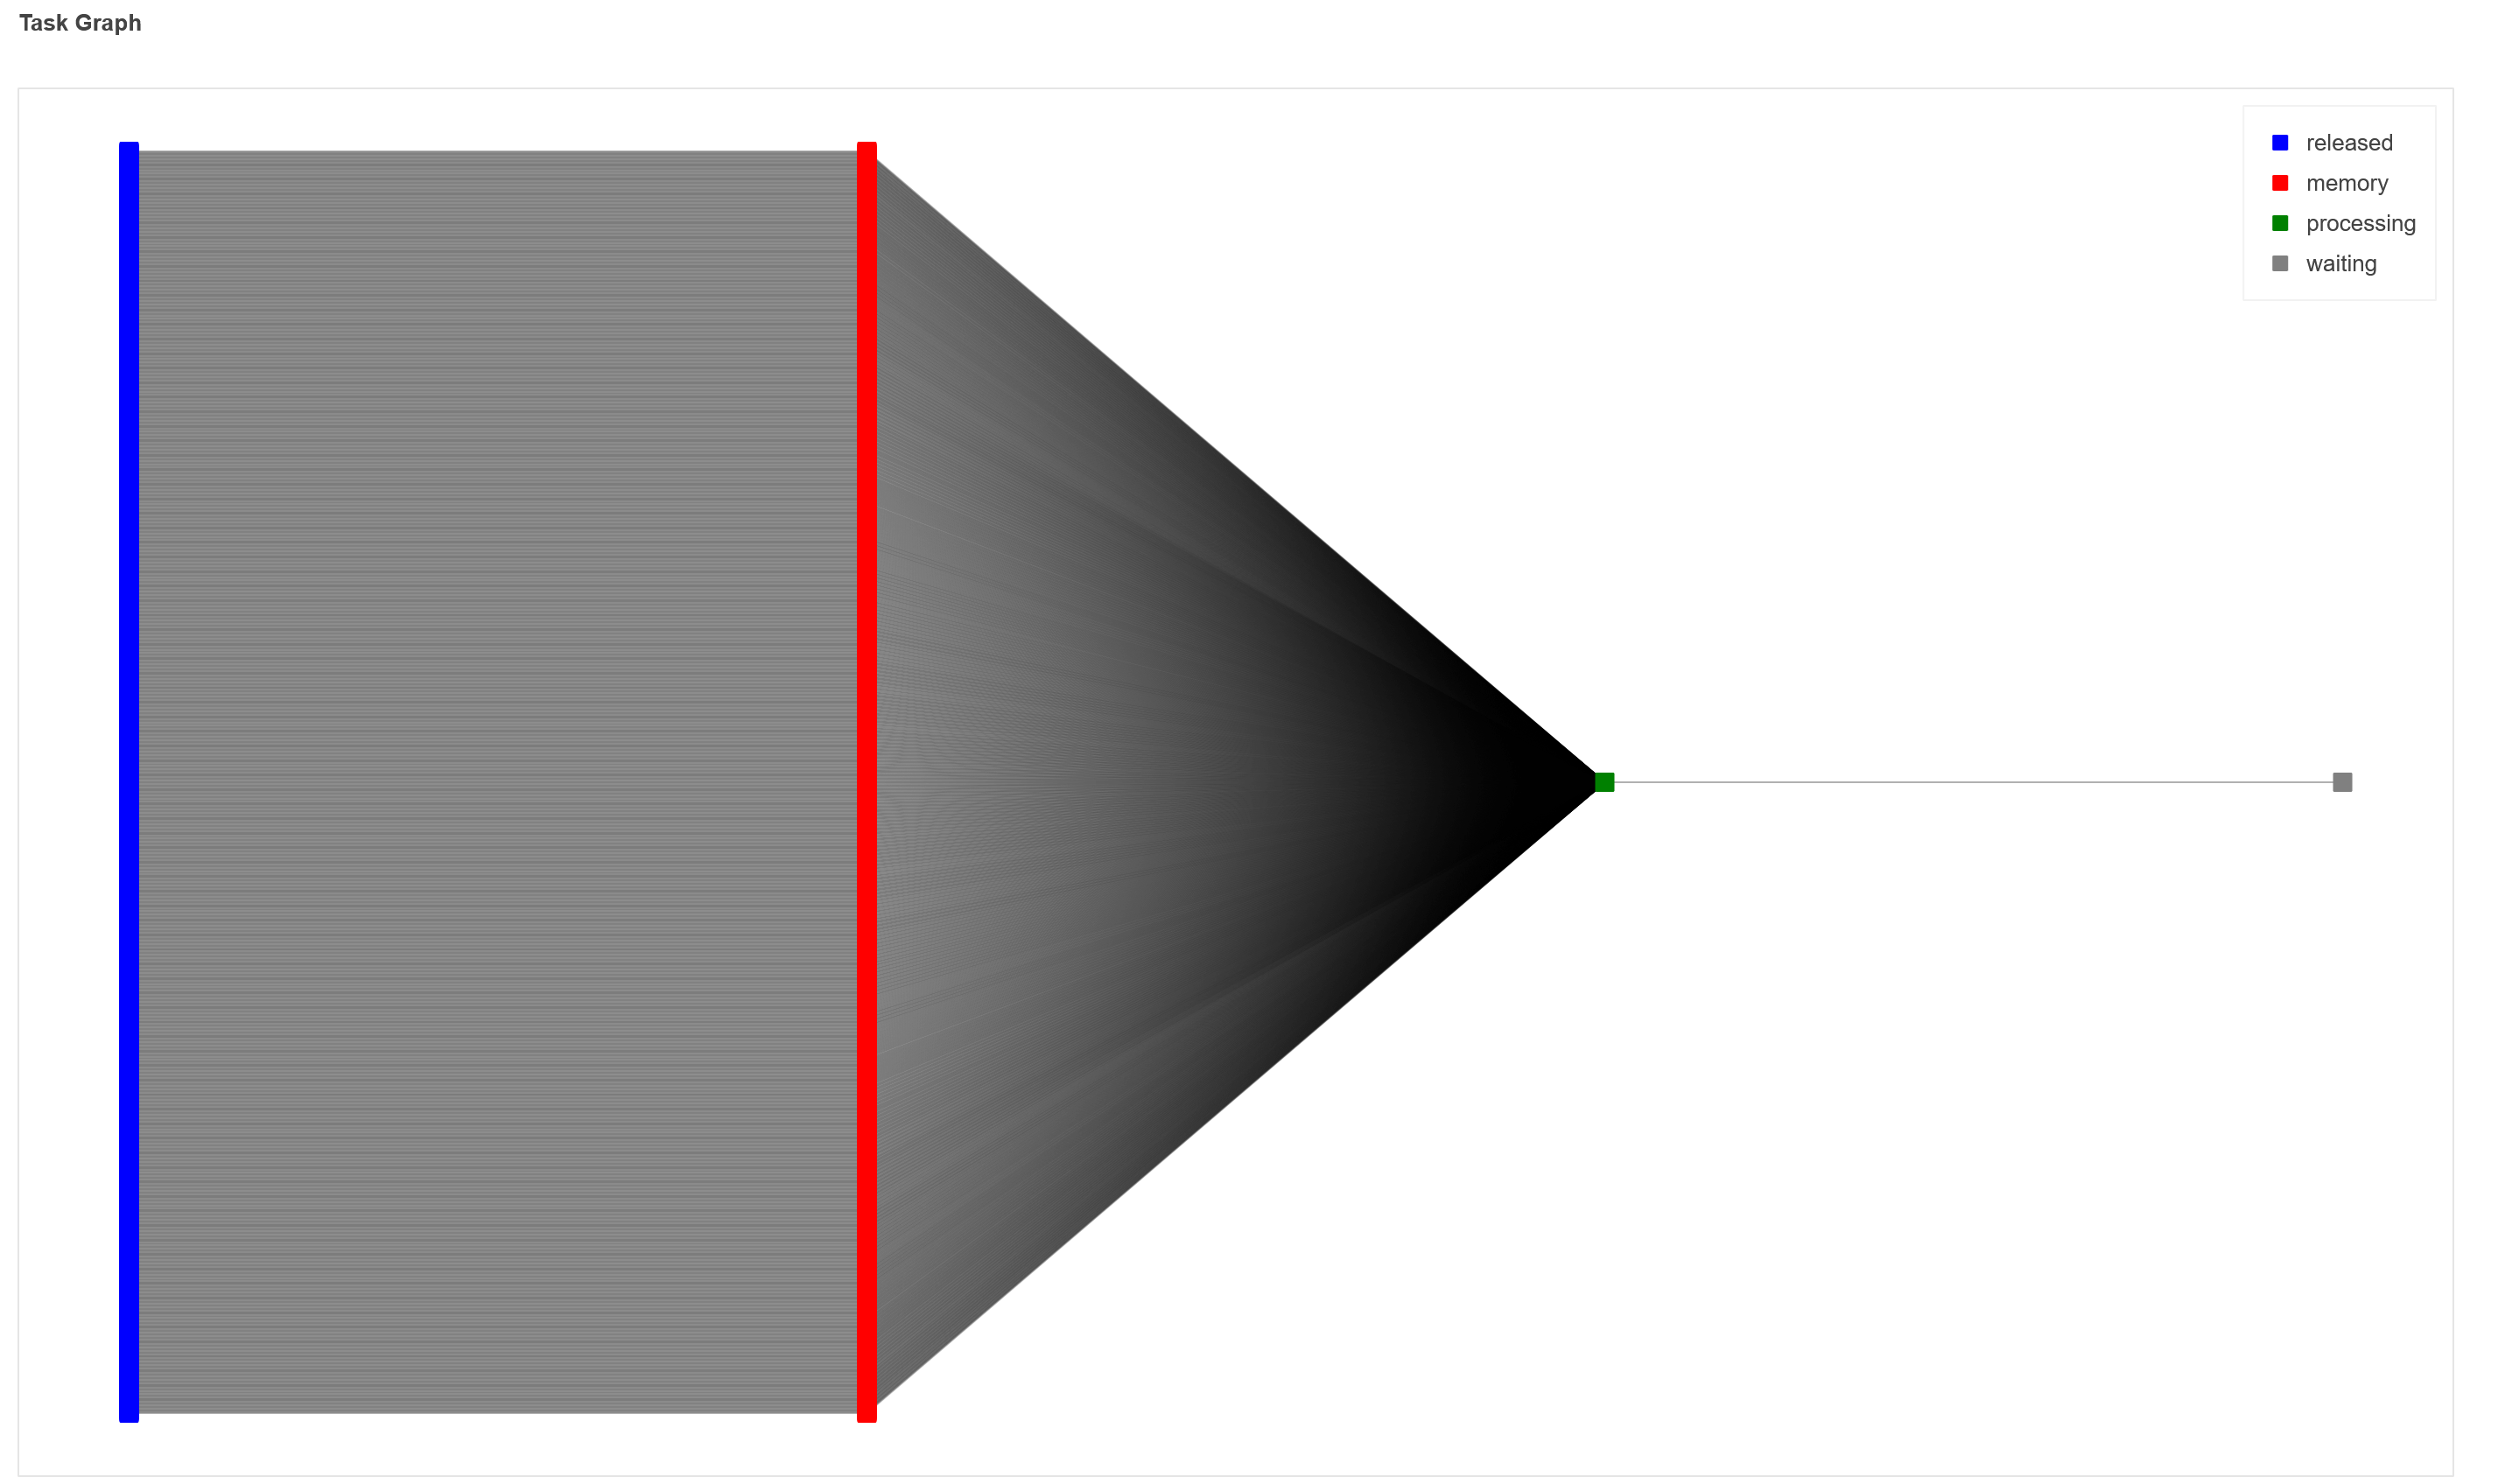

Upon reviewing Dask documentation and recommendations for performance troubleshooting further, I found out, that each partition should be ideally around 100MB in size. My Wikipedia bag of size around 1GB, however, was split in more than 1300 partitions. **I started to implement the repartition function to ensure that my bag has a reasonable number of partitions.**

Thanks to do this, I was able to bring down the time to compute the entire pre_processed dataset down to 10 minutes on my local machine.

However, problems with loading the pdf files in the distributed cluster arised, so I moved back to google colab and decided to keep using the somewhat less informative progress bar.

The computation was progressing much faster, however, at the end, around 97% of the bar progress, the computation stopped and did not move forward. Even though 97% took around 1 minute, the other 3 percent still took around 10 more minutes.

I then tried computing just the books and wikipedia separately. With the books, there were no issues and they could load reasonably quickly in parallel and the progress line was progressing very linearly. Wikipedia on the other hand, even when sampled to a tenth of its original size, displayed the precise pattern of progressing reasonably fast and then stopping at 97% for another 8 minutes.

I was then able to narrow down the bottleneck to the initial loading of th files into the bag using read_text. I tried using various methods, such as loading just file names and mapping the files onto the names manually. This worked only until I wanted to flatten the files so that each line could be one item in the bag. I used Github Copilot (GPT 5.2) to ask about why having many items in a bag is a problem, and I got the answer, that having many objects simply creates overhead and calculating the graph for millions of sentences might be more expensive than their actual processing.

Having identified the issue, if I wanted to analyse the whole Wikipedia, I would let bigger blocks of text be the items in the bag and I would analyze them in serial to produce aggregate values for each block. However, since I had already built all the functions around modifying and analyzing sentences, and because the goal is not to analyze the entire Wikipedia, I decided that I will use **random sampling to obtain a body of text that will represent Wikipedia** without producing millions of sentences.

In [27]:
all_text_phonemes = pre_processed_text.map(lambda x: (x[0], to_phonemes(x[1])))

In [28]:
all_text_phonemes.take(3)

(('wiki', 'tlustá hora kudlofská frxovina m'),
 ('wiki',
  'tlustá hora metri nad mořem je frxol nad jižňí čásťí zlína od roku zde stojí visílač českíx raďiokomuňikací'),
 ('wiki', 'rozhledna lesopark a zoo na tlusté hoře'))

## Measuring softeness

In [29]:
# @title Utility Functions

# the normalised matrix of means of user ratings of each consonant phoneme
ratings_matrix = generate_matrix_of_means(pre_processed_survey)

vowels = ['a', 'á', 'e', 'é', 'i', 'í', 'o', 'ó', 'u', 'ú', 'ů', 'y', 'ý'] # the list was generated by Microsoft Copilot and checked for accuracy

# returns the number of vowels
def n_vowels(word: str) -> int:

  v_count = 0

  # counts the vowels
  for ch in word:
    if ch in vowels:
      v_count += 1

  # returns the proportion of vowels
  return v_count

# converts a word to a dask array (for the purpose of evaluating my research question, this is unnecessary, and regular numpy array would suffice, however, it demonstrates the use of a dask array for the purposes of the project)
def word_array(word: str):
  word_arr = da.from_array(np.zeros(27))
  char_num_dict = {}

  # creates a dictionnary of phonemes to position for easy lookup
  for i in range(27):
    char_num_dict[consonant_phonemes[i]] = i

  for ch in word:
    if ch in char_num_dict:
      word_arr[char_num_dict[ch]] += 1

  return word_arr

def softness(word: str) -> float:
  # vowels are assumed to have softness 1, and the mean softness of each phoneme is the resulting softness
  softness = (da.dot(word_array(word), ratings_matrix) + n_vowels(word))/len(word)
  return softness


In [30]:
assert n_vowels('vést') == 1
assert n_vowels('v') == 0
assert n_vowels('aaa') == 3

Pdfium can sometimes have difficulties with parallel processing due to its low level implementation. This could be one of the reasons why when trying to convert to a dask dataframe without intermediary computation, pdfium throws errors. Persist has been used to prevent the errors.

In [31]:
with ProgressBar():
  new = all_text_phonemes.filter(lambda x: x[0] == 'babicka_bozena_nemcova' or x[0] == 'noc_na_karlstejne_jaroslav_vrchlicky').persist()

[########################################] | 100% Completed | 41.51 s


In [32]:
dataset = new.to_dataframe(meta=[("source", "object"), ("sentence", "object")])

In [33]:
dataset.compute().head(10)

,source,sentence
0,babicka_bozena_nemcova,úvoddávno dávno jiš tomu co jsem posledňe se ď...
1,babicka_bozena_nemcova,mňe ale neumřela obras její otťisknud v duši m...
2,babicka_bozena_nemcova,ti jsi ale vždi říkala neňí na svjeťe človjek ...
3,babicka_bozena_nemcova,babička mňela sina a dvje tceri nejstarší žila...
4,babicka_bozena_nemcova,nežila osamotňelá ve své xaloupce fšickňi obiv...
5,babicka_bozena_nemcova,tu najednou př̥išel babičce lizd z vídňe od ne...
6,babicka_bozena_nemcova,jakého to očekáváňí jakého radováňí na starém ...
7,babicka_bozena_nemcova,oni znali více babiček podobi jejix se jim v h...
8,babicka_bozena_nemcova,z vozu slézá žena v bílé plaxetce f selském ob...
9,babicka_bozena_nemcova,obďivujou tmaví kožíšek s dlouhími varhánkami ...


# Separately used scripts

Originally, the Czech Wikipedia dump file consist of one big compressed file with Wikipedia's original formatting. The following script separates the dump file into multiple smaller chunks, each containing several articles, and extracts the text from the article. The script was run separately, because WikiExtractor needed to be run in an older environment.

In [34]:
# @title WikiExtractor

# !python3.10 -m wikiextractor.WikiExtractor \ --output extracted \ cswiki-latest-pages-articles.xml.bz2

The raw survey dataset contained some personally identifiable information such as name, IP addresses and location. To maintain the original format of the dataframe for the purposes of this project, while keeping personally identifiable data private, the following script was used separately to anonymize the raw data downloaded from Qualtrics

In [35]:
# @title Survey Data Anonymizer

# import pandas as pd

# data = pd.read_csv('raw_data.csv')
# data[['IPAddress', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'LocationLatitude', 'LocationLongitude']] = 'anonymized'
# data.to_csv('anonymized_data.csv')